<a href="https://colab.research.google.com/github/hafsaduman/Calculator/blob/master/Sat'nDebsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
pip install spacetrack

In [19]:
pip install pyorbital


In [20]:
pip install sgp4

In [21]:
!pip install skyfield scipy pandas numpy

# UYDU

In [22]:
from spacetrack import SpaceTrackClient

# Space-Track Giriş Bilgileri
st = SpaceTrackClient(identity='yusuftarik2001@hotmail.com', password='hafsatarik1453.')

# Takip edilecek uyduların NORAD ID'leri
sat_ids = [60233, 50212, 47306, 40984, 39522, 39152, 41882]

print("🛰️ Adım 1: Uydu verileri Space-Track üzerinden çekiliyor...")

try:
    # Verileri çek
    tle_raw = st.gp(norad_cat_id=sat_ids, format='tle')

    # Dosyaya kaydet
    with open("uydular_tle.txt", "w", encoding="utf-8") as file:
        file.write(tle_raw.strip())

    print("✅ Başarılı! Veriler 'uydular_tle.txt' dosyasına kaydedildi.")
except Exception as e:
    print(f"❌ Hata oluştu: {e}")

🛰️ Adım 1: Uydu verileri Space-Track üzerinden çekiliyor...
✅ Başarılı! Veriler 'uydular_tle.txt' dosyasına kaydedildi.


# Enkaz

In [23]:
from spacetrack import SpaceTrackClient

# Space-Track Giriş Bilgileri
st = SpaceTrackClient(identity='yusuftarik2001@hotmail.com', password='hafsatarik1453.')

print("🗑️ Adım 2: Uydularımıza 'Özel' Uzay Enkazı Verileri Çekiliyor...")

try:
    # 1. LEO BÖLGESİ ÇÖPLERİ (Göktürk Uyduları İçin)
    # API'de yükseklik filtreleri PERIAPSIS ve APOAPSIS olarak geçer.
    print("   -> LEO (Alçak Yörünge) bölgesi taranıyor (400-900 km)...")
    leo_debris_raw = st.gp(
        object_type='debris',
        periapsis='400--900',
        apoapsis='400--900',
        limit=400,
        format='tle'
    )

    # 2. GEO BÖLGESİ ÇÖPLERİ (Türksat Uyduları İçin)
    # Türksat uyduları ~35.786 km'dedir.
    print("   -> GEO (Yer Sabit Yörünge) bölgesi taranıyor (35000-36500 km)...")
    geo_debris_raw = st.gp(
        object_type='debris',
        periapsis='35000--36500',
        apoapsis='35000--36500',
        limit=400,
        format='tle'
    )

    # Verileri birleştir (Boş satırları temizleyerek)
    tum_enkazlar = leo_debris_raw.strip() + "\n" + geo_debris_raw.strip()

    # Dosyaya kaydet
    with open("enkazlar_tle.txt", "w", encoding="utf-8") as file:
        file.write(tum_enkazlar.strip())

    print(f"\n✅ Başarılı! Hedeflenen enkaz verileri 'enkazlar_tle.txt' dosyasına kaydedildi.")
    print(f"📍 Toplam çekilen TLE satırı: {len(tum_enkazlar.splitlines())}")

except Exception as e:
    print(f"❌ Hata oluştu: {e}")
    print("\n💡 İpucu: Eğer 'periapsis' hatası devam ederse, kütüphane sürümünden kaynaklı olabilir.")
    print("Alternatif olarak sadece 'limit=1000' kullanarak genel bir liste de çekebiliriz.")

🗑️ Adım 2: Uydularımıza 'Özel' Uzay Enkazı Verileri Çekiliyor...
   -> LEO (Alçak Yörünge) bölgesi taranıyor (400-900 km)...
   -> GEO (Yer Sabit Yörünge) bölgesi taranıyor (35000-36500 km)...

✅ Başarılı! Hedeflenen enkaz verileri 'enkazlar_tle.txt' dosyasına kaydedildi.
📍 Toplam çekilen TLE satırı: 948


# Veri Hazırlama


In [24]:
import numpy as np
import pandas as pd
from skyfield.api import EarthSatellite, load
from scipy.spatial import KDTree
from datetime import timedelta

# --- AYARLAR ---
ts = load.timescale()
now = ts.now()
prediction_window = 48
step_hours = 2

# Uydu İsim Sözlüğü (NORAD ID -> İsim)
uydu_isimleri = {
    60233: "TURKSAT 6A", 50212: "TURKSAT 5B", 47306: "TURKSAT 5A",
    40984: "TURKSAT 4B", 39522: "TURKSAT 4A", 39152: "GOKTURK-2", 41882: "GOKTURK-1"
}

def load_tle_file(filename):
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    return [EarthSatellite(lines[i], lines[i+1], lines[i][:10], ts) for i in range(0, len(lines), 2)]

# Dosyaları yükle
uydular = load_tle_file('uydular_tle.txt')
enkazlar = load_tle_file('enkazlar_tle.txt')

# Sonuçların toplanacağı ana liste
filtered_results = []

print("🚀 Analiz Motoru Çalışıyor...")

# --- GERÇEK VERİ ANALİZ DÖNGÜSÜ ---
for hour in range(0, prediction_window, step_hours):
    t = now + timedelta(hours=hour)

    debris_data = []
    for d in enkazlar:
        out = d.at(t)
        if np.all(np.isfinite(out.position.km)):
            debris_data.append({'obj': d, 'pos': out.position.km, 'vel': out.velocity.km_per_s})

    if not debris_data: continue
    tree = KDTree([d['pos'] for d in debris_data])

    for uydu in uydular:
        sat_out = uydu.at(t)
        sat_pos = sat_out.position.km
        sat_vel = sat_out.velocity.km_per_s

        indices = tree.query_ball_point(sat_pos, r=500.0)

        for idx in indices:
            deb = debris_data[idx]
            dist = np.linalg.norm(sat_pos - deb['pos'])
            rel_vel = np.linalg.norm(np.array(sat_vel) - np.array(deb['vel']))

            if rel_vel > 0.5:
                sat_id = uydu.model.satnum
                # VERİ EKLEME (Sözlük yapısı sabit olmalı)
                filtered_results.append({
                    'Hedef Uydu': uydu_isimleri.get(sat_id, f"SAT-{sat_id}"),
                    'Tehdit Enkaz': f"DEBRIS-{deb['obj'].model.satnum}",
                    'Mesafe (km)': round(dist, 2),
                    'Bagil Hiz (km/s)': round(rel_vel, 2),
                    'Tehlike Skoru': round((rel_vel * 100) / (dist + 1), 2)
                })

# --- FAKE DATA ENJEKSİYONU (Döngü bittikten sonra ekliyoruz) ---
if len(uydular) > 0:
    first_sat_name = uydu_isimleri.get(uydular[0].model.satnum, "TEST-SAT")
    fake_case = {
        'Hedef Uydu': f"🚨 {first_sat_name}",
        'Tehdit Enkaz': "DEBRIS-99999 (TEST)",
        'Mesafe (km)': 12.45,
        'Bagil Hiz (km/s)': 14.80,
        'Tehlike Skoru': 999.99  # Bilinçli olarak en yüksek skor
    }
    filtered_results.append(fake_case)

print(f"✅ Analiz bitti. {len(filtered_results)} vaka hafızaya alındı.")

🚀 Analiz Motoru Çalışıyor...
✅ Analiz bitti. 8 vaka hafızaya alındı.


In [25]:
!pip install plotly

In [26]:
import plotly.graph_objects as go
import numpy as np

def gorsellestir_interaktif(uydu_datalari, enkaz_datalari, kesisimler=None):
    fig = go.Figure()

    # 1. Dünya'yı Temsil Eden Küre (Merkez)
    r = 6371  # Dünya yarıçapı km
    phi, theta = np.mgrid[0.0:np.pi:100j, 0.0:2.0*np.pi:100j]
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    fig.add_trace(go.Surface(x=x, y=y, z=z, opacity=0.3, colorscale='Blues', showscale=False, name='Dünya'))

    # 2. Uyduları Ekle (Türksat, Göktürk vb.)
    for uydu in uydu_datalari:
        fig.add_trace(go.Scatter3d(
            x=[uydu['pos'][0]], y=[uydu['pos'][1]], z=[uydu['pos'][2]],
            mode='markers+text',
            marker=dict(size=6, color='royalblue'),
            text=[uydu['isim']],
            name=f"Uydu: {uydu['isim']}"
        ))

    # 3. Enkazları Ekle
    debris_x = [d['pos'][0] for d in enkaz_datalari]
    debris_y = [d['pos'][1] for d in enkaz_datalari]
    debris_z = [d['pos'][2] for d in enkaz_datalari]
    debris_ids = [f"Debris-{d['id']}" for d in enkaz_datalari]

    fig.add_trace(go.Scatter3d(
        x=debris_x, y=debris_y, z=debris_z,
        mode='markers',
        marker=dict(size=3, color='red', opacity=0.7),
        text=debris_ids,
        name='Uzay Enkazları'
    ))

    # 4. Kritik Kesişim Çizgileri (Eğer risk varsa araya çizgi çeker)
    if kesisimler:
        for k in kesisimler:
            fig.add_trace(go.Scatter3d(
                x=[k['uydu_pos'][0], k['enkaz_pos'][0]],
                y=[k['uydu_pos'][1], k['enkaz_pos'][1]],
                z=[k['uydu_pos'][2], k['enkaz_pos'][2]],
                mode='lines',
                line=dict(color='yellow', width=4),
                name='RİSK HATTI'
            ))

    # Grafik Ayarları (Mouse etkileşimi için)
    fig.update_layout(
        title="İnteraktif Uydu ve Enkaz İzleme Paneli",
        scene=dict(
            xaxis_title='X (km)',
            yaxis_title='Y (km)',
            zaxis_title='Z (km)',
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

# Not: Fonksiyonu elindeki verilerle çağırman yeterlidir.

# Görselleştirme

📂 Yerel dosyalar yükleniyor...

📊 ADIM 1 - SİSTEM ANALİZ RAPORU | TSİ: 14:29:08

🗑️ 474 adet enkaz hesaplanıyor ve yörüngeleri çiziliyor...


/tmp/ipykernel_2767/3520841009.py:77: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).




🛰️ GÖKTÜRK-2
   LOCAL TIME    : 14:29:08
   UTC           : 11:29:08
   LATITUDE      :   -82.16
   LONGITUDE     :   -83.35
   ALTITUDE [km] :   596.02
   ALTITUDE [mi] :   370.35
   SPEED [km/s]  :     7.55
   SPEED [mi/s]  :     4.69
   AZIMUTH       : 275.8 W

🛰️ TURKSAT 4A
   LOCAL TIME    : 14:29:08
   UTC           : 11:29:08
   LATITUDE      :     0.04
   LONGITUDE     :    42.04
   ALTITUDE [km] : 35792.65
   ALTITUDE [mi] : 22240.51
   SPEED [km/s]  :     3.07
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 41.2 NE

🛰️ TURKSAT 4B
   LOCAL TIME    : 14:29:08
   UTC           : 11:29:08
   LATITUDE      :    -0.00
   LONGITUDE     :    50.03
   ALTITUDE [km] : 35786.72
   ALTITUDE [mi] : 22236.83
   SPEED [km/s]  :     3.08
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 49.2 NE

🛰️ GÖKTÜRK-1
   LOCAL TIME    : 14:29:08
   UTC           : 11:29:08
   LATITUDE      :     1.39
   LONGITUDE     :   123.56
   ALTITUDE [km] : 35797.00
   ALTITUDE [mi] : 22243.22
   SPEED [km/s]  :   

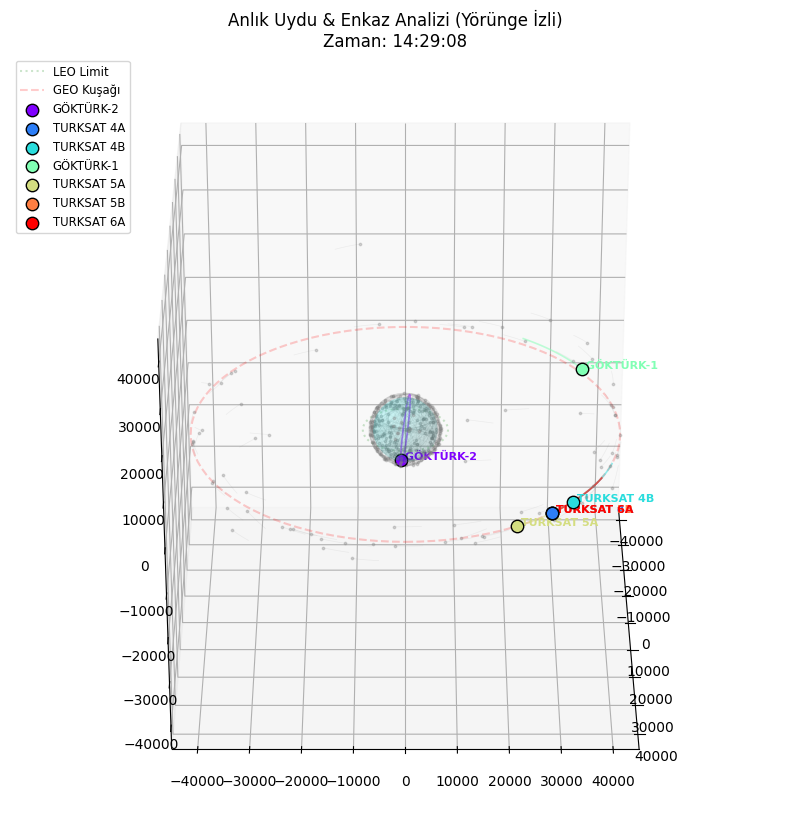


📊 ADIM 2 - SİSTEM ANALİZ RAPORU | TSİ: 14:29:33

🗑️ 474 adet enkaz hesaplanıyor ve yörüngeleri çiziliyor...

🛰️ GÖKTÜRK-2
   LOCAL TIME    : 14:29:33
   UTC           : 11:29:33
   LATITUDE      :   -82.17
   LONGITUDE     :   -94.87
   ALTITUDE [km] :   595.80
   ALTITUDE [mi] :   370.21
   SPEED [km/s]  :     7.55
   SPEED [mi/s]  :     4.69
   AZIMUTH       : 264.4 W

🛰️ TURKSAT 4A
   LOCAL TIME    : 14:29:33
   UTC           : 11:29:33
   LATITUDE      :     0.04
   LONGITUDE     :    42.04
   ALTITUDE [km] : 35792.68
   ALTITUDE [mi] : 22240.53
   SPEED [km/s]  :     3.07
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 41.3 NE

🛰️ TURKSAT 4B
   LOCAL TIME    : 14:29:33
   UTC           : 11:29:33
   LATITUDE      :    -0.00
   LONGITUDE     :    50.03
   ALTITUDE [km] : 35786.73
   ALTITUDE [mi] : 22236.84
   SPEED [km/s]  :     3.08
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 49.3 NE

🛰️ GÖKTÜRK-1
   LOCAL TIME    : 14:29:33
   UTC           : 11:29:33
   LATITUDE      :     1

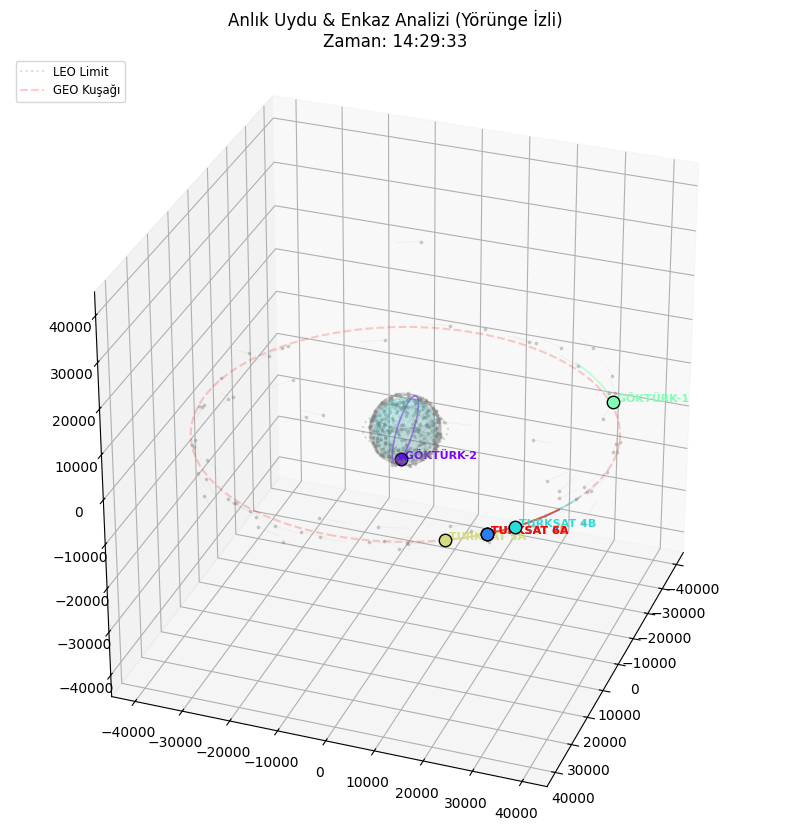


📊 ADIM 3 - SİSTEM ANALİZ RAPORU | TSİ: 14:29:50

🗑️ 474 adet enkaz hesaplanıyor ve yörüngeleri çiziliyor...

🛰️ GÖKTÜRK-2
   LOCAL TIME    : 14:29:50
   UTC           : 11:29:50
   LATITUDE      :   -82.01
   LONGITUDE     :  -102.52
   ALTITUDE [km] :   595.64
   ALTITUDE [mi] :   370.12
   SPEED [km/s]  :     7.55
   SPEED [mi/s]  :     4.69
   AZIMUTH       : 256.8 W

🛰️ TURKSAT 4A
   LOCAL TIME    : 14:29:50
   UTC           : 11:29:50
   LATITUDE      :     0.04
   LONGITUDE     :    42.04
   ALTITUDE [km] : 35792.70
   ALTITUDE [mi] : 22240.55
   SPEED [km/s]  :     3.07
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 41.4 NE

🛰️ TURKSAT 4B
   LOCAL TIME    : 14:29:50
   UTC           : 11:29:50
   LATITUDE      :    -0.00
   LONGITUDE     :    50.03
   ALTITUDE [km] : 35786.74
   ALTITUDE [mi] : 22236.84
   SPEED [km/s]  :     3.08
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 49.4 NE

🛰️ GÖKTÜRK-1
   LOCAL TIME    : 14:29:50
   UTC           : 11:29:50
   LATITUDE      :     1

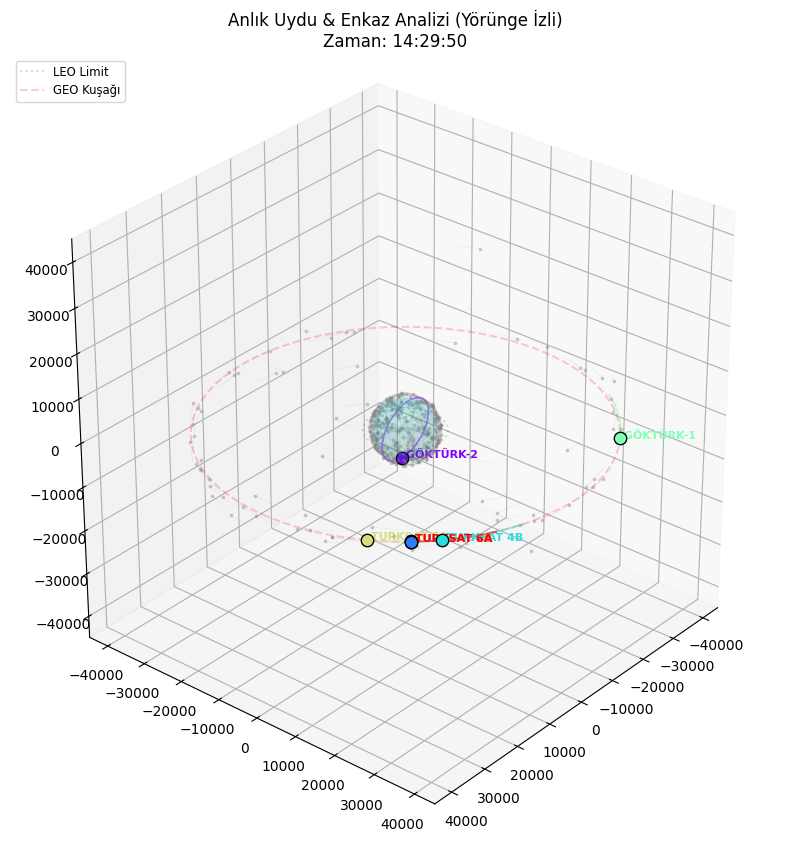


📊 ADIM 4 - SİSTEM ANALİZ RAPORU | TSİ: 14:30:06

🗑️ 474 adet enkaz hesaplanıyor ve yörüngeleri çiziliyor...

🛰️ GÖKTÜRK-2
   LOCAL TIME    : 14:30:06
   UTC           : 11:30:06
   LATITUDE      :   -81.73
   LONGITUDE     :  -109.34
   ALTITUDE [km] :   595.50
   ALTITUDE [mi] :   370.03
   SPEED [km/s]  :     7.55
   SPEED [mi/s]  :     4.69
   AZIMUTH       : 250.1 W

🛰️ TURKSAT 4A
   LOCAL TIME    : 14:30:06
   UTC           : 11:30:06
   LATITUDE      :     0.04
   LONGITUDE     :    42.04
   ALTITUDE [km] : 35792.72
   ALTITUDE [mi] : 22240.56
   SPEED [km/s]  :     3.07
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 41.5 NE

🛰️ TURKSAT 4B
   LOCAL TIME    : 14:30:06
   UTC           : 11:30:06
   LATITUDE      :    -0.00
   LONGITUDE     :    50.03
   ALTITUDE [km] : 35786.75
   ALTITUDE [mi] : 22236.85
   SPEED [km/s]  :     3.08
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 49.4 NE

🛰️ GÖKTÜRK-1
   LOCAL TIME    : 14:30:06
   UTC           : 11:30:06
   LATITUDE      :     1

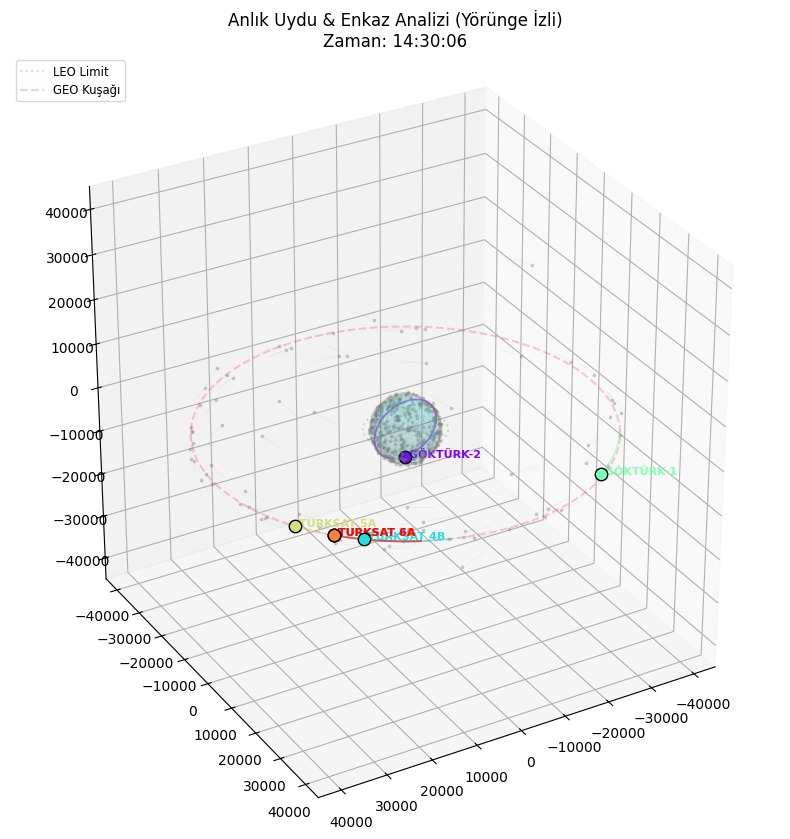


📊 ADIM 5 - SİSTEM ANALİZ RAPORU | TSİ: 14:30:23

🗑️ 474 adet enkaz hesaplanıyor ve yörüngeleri çiziliyor...

🛰️ GÖKTÜRK-2
   LOCAL TIME    : 14:30:23
   UTC           : 11:30:23
   LATITUDE      :   -81.32
   LONGITUDE     :  -116.03
   ALTITUDE [km] :   595.34
   ALTITUDE [mi] :   369.93
   SPEED [km/s]  :     7.55
   SPEED [mi/s]  :     4.69
   AZIMUTH       : 243.5 SW

🛰️ TURKSAT 4A
   LOCAL TIME    : 14:30:23
   UTC           : 11:30:23
   LATITUDE      :     0.04
   LONGITUDE     :    42.04
   ALTITUDE [km] : 35792.74
   ALTITUDE [mi] : 22240.57
   SPEED [km/s]  :     3.07
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 41.5 NE

🛰️ TURKSAT 4B
   LOCAL TIME    : 14:30:23
   UTC           : 11:30:23
   LATITUDE      :    -0.00
   LONGITUDE     :    50.03
   ALTITUDE [km] : 35786.76
   ALTITUDE [mi] : 22236.85
   SPEED [km/s]  :     3.08
   SPEED [mi/s]  :     1.91
   AZIMUTH       : 49.5 NE

🛰️ GÖKTÜRK-1
   LOCAL TIME    : 14:30:23
   UTC           : 11:30:23
   LATITUDE      :     

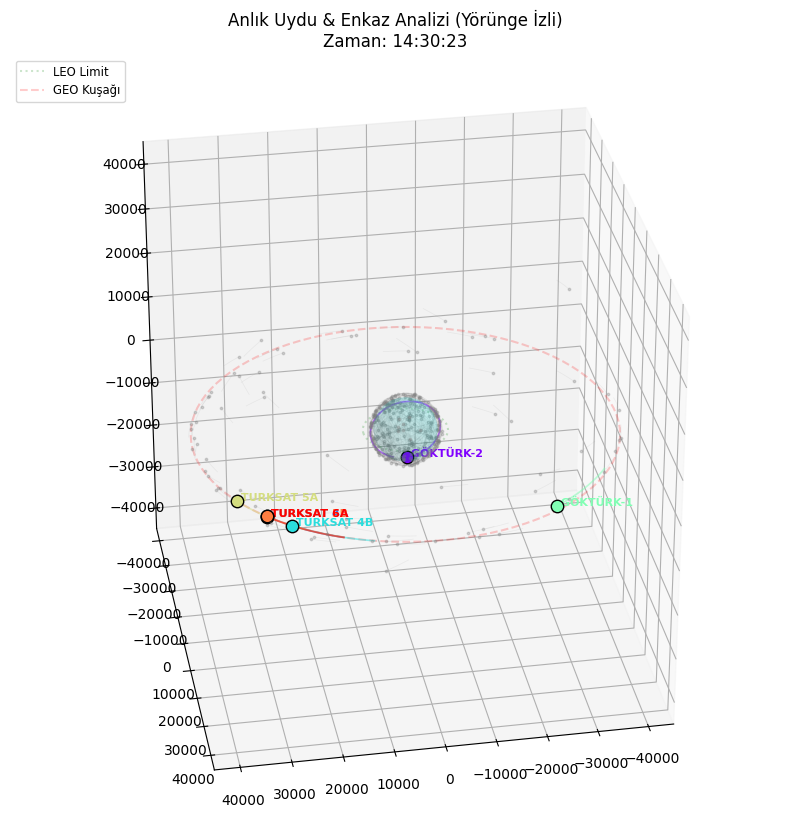


✅ Analiz sonlandırıldı.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sgp4.api import Satrec, jday
from datetime import datetime, timedelta
import time
import os

# --- Uydu İsimlendirme Sözlüğü ---
sat_ids_map = {
    60233: "TURKSAT 6A", 50212: "TURKSAT 5B", 47306: "TURKSAT 5A",
    40984: "TURKSAT 4B", 39522: "TURKSAT 4A", 39152: "GÖKTÜRK-2", 41882: "GÖKTÜRK-1"
}

# --- Birim Dönüşüm Sabitleri ---
KM_TO_MILE = 0.621371

# --- Teknik Yardımcı Fonksiyon: ECI -> Enlem/Boylam/Hız/Azimut ---
def eci_to_lla(r, v, jd, fr):
    x, y, z = r
    dist_center = np.linalg.norm(r)
    alt_km = dist_center - 6371
    lat = np.degrees(np.arcsin(z / dist_center))

    # Yıldız zamanı hesabı
    t = (jd + fr - 2451545.0) / 36525.0
    gmst = 280.46061837 + 360.98564736629 * (jd + fr - 2451545.0) + \
           0.000387933 * t**2 - t**3 / 38710000.0
    lon = (np.degrees(np.arctan2(y, x)) - gmst) % 360
    if lon > 180: lon -= 360

    # Hız Hesaplamaları
    speed_km_s = np.linalg.norm(v)

    # Basit Azimut Hesaplaması (Yaklaşık Yön Tayini)
    az_angle = (np.degrees(np.arctan2(y, x))) % 360
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
    az_str = f"{az_angle:.1f} {directions[int((az_angle + 22.5) / 45)]}"

    return {
        "lat": lat, "lon": lon,
        "alt_km": alt_km, "alt_mi": alt_km * KM_TO_MILE,
        "speed_km": speed_km_s, "speed_mi": speed_km_s * KM_TO_MILE,
        "az": az_str
    }

# --- Dosyadan TLE Okuma ---
def load_tle_from_file(filename, is_debris=False):
    objects = {}
    if not os.path.exists(filename): return objects
    with open(filename, "r", encoding="utf-8") as file:
        lines = file.read().strip().split('\n')
    for i in range(0, len(lines), 2):
        if i+1 >= len(lines): break
        line1, line2 = lines[i], lines[i+1]
        obj_id = int(line1.split()[1].replace('U', ''))
        name = f"DEB-{obj_id}" if is_debris else sat_ids_map.get(obj_id, f"Unknown-{obj_id}")
        objects[name] = Satrec.twoline2rv(line1, line2)
    return objects

# ==========================================
# ANA ANALİZ BAŞLANGICI
# ==========================================

# Verileri Yükle
print("📂 Yerel dosyalar yükleniyor...")
satellites = load_tle_from_file("uydular_tle.txt", is_debris=False)
debris_objects = load_tle_from_file("enkazlar_tle.txt", is_debris=True)

plt.ion()

# Takip Ayarları
step_count = 5
interval_seconds = 10
orbit_propagation_minutes = 90 # Yörünge çizgisinin uzunluğu (bir tam tur)

for step in range(step_count):
    now_utc = datetime.utcnow()
    now_tr = now_utc + timedelta(hours=3)
    jd, fr = jday(now_utc.year, now_utc.month, now_utc.day, now_utc.hour, now_utc.minute, now_utc.second)

    # Temiz Konsol Çıktısı (Teknik Veriler)
    print(f"\n" + "="*60)
    print(f"📊 ADIM {step+1} - SİSTEM ANALİZ RAPORU | TSİ: {now_tr.strftime('%H:%M:%S')}")
    print("="*60)

    # 3D Grafik Hazırlığı
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=30, azim=45)   # Kamera açısı
    ax.set_box_aspect([1,1,1])       # Eksenleri eşitle
    ax.set_proj_type('persp')        # Perspektif
    ax.view_init(elev=30, azim=step * 20)
    # Dünya Çizimi (Şeffaf Mavi Sfer)
    u, v_sphere = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
    ax.plot_surface(6371*np.cos(u)*np.sin(v_sphere),
                    6371*np.sin(u)*np.sin(v_sphere),
                    6371*np.cos(v_sphere), alpha=0.1, color='cyan')

    # Yörünge Katmanları Referans Çizgileri
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot((6371+2000)*np.cos(theta), (6371+2000)*np.sin(theta), 0, color='green', linestyle=':', alpha=0.2, label='LEO Limit')
    ax.plot((6371+35786)*np.cos(theta), (6371+35786)*np.sin(theta), 0, color='red', linestyle='--', alpha=0.2, label='GEO Kuşağı')

    # --- 1. ENKAZLARI HESAPLA, ÇİZ VE YÖRÜNGELERİNİ EKLE ---
    deb_pos_list = []
    print(f"\n🗑️ {len(debris_objects)} adet enkaz hesaplanıyor ve yörüngeleri çiziliyor...")

    for d_name, d_obj in debris_objects.items():
        # Anlık Konum
        e, r, v = d_obj.sgp4(jd, fr)
        if e == 0:
            deb_pos_list.append((d_name, np.array(r)))
            ax.scatter(r[0], r[1], r[2], color='gray', s=3, alpha=0.3)

            # --- YÖRÜNGE ÇİZGİSİ (Enkaz İçin - Kısa İz) ---
            orbit_path = []
            for min_off in range(0, 30, 2): # Gelecekteki 30 dakikayı hesapla (seyrek)
                future_time = now_utc + timedelta(minutes=min_off)
                jd_f, fr_f = jday(future_time.year, future_time.month, future_time.day, future_time.hour, future_time.minute, future_time.second)
                e_f, r_f, v_f = d_obj.sgp4(jd_f, fr_f)
                if e_f == 0:
                    orbit_path.append(r_f)

            if orbit_path:
                orbit_path = np.array(orbit_path)
                ax.plot(orbit_path[:,0], orbit_path[:,1], orbit_path[:,2], color='gray', linestyle='-', alpha=0.1, linewidth=0.5)

    # --- 2. UYDULARI HESAPLA, ÇİZ VE YÖRÜNGELERİNİ EKLE ---
    colors = plt.cm.rainbow(np.linspace(0, 1, len(satellites)))

    for i, (name, sat_obj) in enumerate(satellites.items()):
        # Anlık Konum ve Teknik Veriler
        e, r, v = sat_obj.sgp4(jd, fr)
        if e == 0:
            data = eci_to_lla(r, v, jd, fr)

            # KONSOL ÇIKTISI (İstediğin Format)
            print(f"\n🛰️ {name.upper()}")
            print(f"   LOCAL TIME    : {now_tr.strftime('%H:%M:%S')}")
            print(f"   UTC           : {now_utc.strftime('%H:%M:%S')}")
            print(f"   LATITUDE      : {data['lat']:>8.2f}")
            print(f"   LONGITUDE     : {data['lon']:>8.2f}")
            print(f"   ALTITUDE [km] : {data['alt_km']:>8.2f}")
            print(f"   ALTITUDE [mi] : {data['alt_mi']:>8.2f}")
            print(f"   SPEED [km/s]  : {data['speed_km']:>8.2f}")
            print(f"   SPEED [mi/s]  : {data['speed_mi']:>8.2f}")
            print(f"   AZIMUTH       : {data['az']}")

            # GRAFİK ÇİZİMİ (Anlık Nokta)
            ax.scatter(r[0], r[1], r[2], color=colors[i], s=80, edgecolors='black', label=name if step==0 else "")
            ax.text(r[0], r[1], r[2], f" {name}", color=colors[i], fontsize=8, fontweight='bold')

            # --- YÖRÜNGE ÇİZGİSİ (Uydu İçin - Tam Tur) ---
            orbit_path = []
            # Gelecekteki bir tam turu hesapla (daha sık örnekleme)
            for min_off in range(0, orbit_propagation_minutes + 1, 1):
                future_time = now_utc + timedelta(minutes=min_off)
                jd_f, fr_f = jday(future_time.year, future_time.month, future_time.day, future_time.hour, future_time.minute, future_time.second)
                e_f, r_f, v_f = sat_obj.sgp4(jd_f, fr_f)
                if e_f == 0:
                    orbit_path.append(r_f)

            if orbit_path:
                orbit_path = np.array(orbit_path)
                ax.plot(orbit_path[:,0], orbit_path[:,1], orbit_path[:,2], color=colors[i], linestyle='-', alpha=0.5, linewidth=1.2)

            # --- RİSK ANALİZİ (Çarpışma Kontrolü) ---
            for d_name, d_pos in deb_pos_list:
                dist = np.linalg.norm(np.array(r) - d_pos)
                if dist < 250: # 250 km altı riskli bölge
                    print(f"   ⚠️ WARNING: Near Collision with {d_name} ({dist:.2f} km)")
                    # Grafikte Riskli Çöpü Kırmızı Yap ve Çizgi Çek
                    ax.scatter(d_pos[0], d_pos[1], d_pos[2], color='red', s=15)
                    ax.plot([r[0], d_pos[0]], [r[1], d_pos[1]], [r[2], d_pos[2]], color='red', linewidth=2, alpha=0.8)

    # Grafik Ayarları
    limit = 45000
    ax.set_xlim([-limit, limit]); ax.set_ylim([-limit, limit]); ax.set_zlim([-limit, limit])
    ax.set_title(f"Anlık Uydu & Enkaz Analizi (Yörünge İzli)\nZaman: {now_tr.strftime('%H:%M:%S')}")
    ax.legend(loc='upper left', fontsize='small')

    plt.draw()
    plt.pause(interval_seconds)
    plt.close(fig)

print("\n✅ Analiz sonlandırıldı.")

In [28]:
import numpy as np
import plotly.graph_objects as go
from sgp4.api import Satrec, jday
from datetime import datetime, timedelta
import os

# --- Uydu İsimlendirme ---
sat_ids_map = {
    60233: "TURKSAT 6A", 50212: "TURKSAT 5B", 47306: "TURKSAT 5A",
    40984: "TURKSAT 4B", 39522: "TURKSAT 4A",
    39152: "GÖKTÜRK-2", 41882: "GÖKTÜRK-1"
}

# --- 1. TLE OKUMA FONKSİYONU ---
def load_tle(filename, is_debris=False):
    sats = {}
    if not os.path.exists(filename):
        print(f"⚠️ Uyarı: {filename} bulunamadı!")
        return sats

    with open(filename) as f:
        lines = f.read().splitlines()

    for i in range(0, len(lines), 2):
        if i + 1 >= len(lines): break
        l1, l2 = lines[i], lines[i+1]
        sat_id = int(l1.split()[1].replace('U',''))

        # Enkazlar ve uydular için farklı isimlendirme
        name = f"DEB-{sat_id}" if is_debris else sat_ids_map.get(sat_id, f"SAT-{sat_id}")
        sats[name] = Satrec.twoline2rv(l1, l2)

    return sats

# --- 2. YAKIN ENKAZLARI BULMA FONKSİYONU ---
def get_closest_debris(satellites, debris, jd, fr, top_n=50):
    distances = []
    for d_name, d_sat in debris.items():
        e_d, r_d, _ = d_sat.sgp4(jd, fr)
        if e_d != 0: continue

        min_dist = float("inf")
        for s_name, s_sat in satellites.items():
            e_s, r_s, _ = s_sat.sgp4(jd, fr)
            if e_s != 0: continue

            dist = np.linalg.norm(np.array(r_s) - np.array(r_d))
            if dist < min_dist:
                min_dist = dist

        distances.append((d_name, d_sat, min_dist))

    # en yakınları seç
    distances.sort(key=lambda x: x[2])
    return distances[:top_n]

# --- 3. VERİLERİ YÜKLE ---
satellites = load_tle("uydular_tle.txt")
debris = load_tle("enkazlar_tle.txt", is_debris=True) # Enkaz verisi eklendi

# --- 4. ZAMAN VE HESAPLAMALAR ---
now = datetime.utcnow()
jd, fr = jday(now.year, now.month, now.day, now.hour, now.minute, now.second)

# Fonksiyon tanımlandıktan sonra çağırıyoruz
closest_debris = get_closest_debris(satellites, debris, jd, fr, top_n=50)

# --- 5. GÖRSELLEŞTİRME ---
fig = go.Figure()

# DÜNYA KÜRE
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)
x = 6371 * np.outer(np.cos(u), np.sin(v))
y = 6371 * np.outer(np.sin(u), np.sin(v))
z = 6371 * np.outer(np.ones(np.size(u)), np.cos(v))

fig.add_surface(x=x, y=y, z=z, opacity=0.3, colorscale='Blues', showscale=False)

# --- DEBRIS (Sadece Uydulara En Yakın 50 Enkaz) ---
for d_name, d_sat, dist_val in closest_debris:
    # Yanlışlıkla 'sat' yazılmıştı, 'd_sat' (debris) olarak düzeltildi
    e, r, v = d_sat.sgp4(jd, fr)
    if e != 0: continue

    x0, y0, z0 = r

    # Renk ataması döngünün içine alındı
    color = 'red' if dist_val < 200 else 'orange' if dist_val < 500 else 'gray'

    # Enkaz Noktası
    fig.add_trace(go.Scatter3d(
        x=[x0], y=[y0], z=[z0],
        mode='markers',
        marker=dict(size=3, color=color),
        name=f"Debris ({dist_val:.1f}km)",
        showlegend=False
    ))

    # Enkaz Yörüngesi
    xs, ys, zs = [], [], []
    for m in range(0, 30, 5):
        t = now + timedelta(minutes=m)
        jd_f, fr_f = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
        e_f, r_f, _ = d_sat.sgp4(jd_f, fr_f) # d_sat kullanıldı
        if e_f == 0:
            xs.append(r_f[0]); ys.append(r_f[1]); zs.append(r_f[2])

    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='lines',
        line=dict(width=1, color=color),
        showlegend=False
    ))

# --- UYDULAR ---
# Uydu döngüsü tamamen bağımsız bir bloğa ayrıldı
for name, sat in satellites.items():
    e, r, v = sat.sgp4(jd, fr)
    if e != 0: continue

    x0, y0, z0 = r

    # Uydu noktası
    fig.add_trace(go.Scatter3d(
        x=[x0], y=[y0], z=[z0],
        mode='markers+text',
        marker=dict(size=6, symbol='diamond'),
        text=[name],
        textposition="top center",
        name=name
    ))

    # Uydu Yörüngesi
    xs, ys, zs = [], [], []
    for m in range(0, 90, 2):
        t = now + timedelta(minutes=m)
        jd_f, fr_f = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
        e_f, r_f, _ = sat.sgp4(jd_f, fr_f)
        if e_f == 0:
            xs.append(r_f[0]); ys.append(r_f[1]); zs.append(r_f[2])

    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='lines',
        line=dict(width=2),
        name=f"{name} Yörünge"
    ))

# --- LAYOUT AYARLARI ---
fig.update_layout(
    title="🛰️ HAFSA: 3D Uydu ve Riskli Enkaz Takip Sistemi",
    template="plotly_dark",
    scene=dict(
        aspectmode='data', # Eksenlerin bozulmasını engeller
        xaxis=dict(title="X (km)", showbackground=True),
        yaxis=dict(title="Y (km)", showbackground=True),
        zaxis=dict(title="Z (km)", showbackground=True)
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

/tmp/ipykernel_2767/862799419.py:62: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



# Conjunction Assessment (Yakınlaşma Taraması)

# Çarpışma Olasılığı

In [29]:
import numpy as np
import pandas as pd
from skyfield.api import EarthSatellite, load
from scipy.spatial import KDTree
from datetime import timedelta

# --- AYARLAR VE SIFIRLAMA ---
ts = load.timescale()
now = ts.now()
prediction_window = 48
step_hours = 2
collision_threshold_km = 500.0
filtered_results = [] # Her çalıştırmada listeyi sıfırlar

# Uydu isim eşleştirmesi (Sunumda profesyonel görünmesi için)
uydu_isimleri = {
    60233: "TURKSAT 6A", 50212: "TURKSAT 5B", 47306: "TURKSAT 5A",
    40984: "TURKSAT 4B", 39522: "TURKSAT 4A", 39152: "GOKTURK-2", 41882: "GOKTURK-1"
}

# TLE dosyalarını yükle
uydular = load_tle_file('uydular_tle.txt')
enkazlar = load_tle_file('enkazlar_tle.txt')

print("🚀 Yörünge Kesişimi ve Bağıl Hız Analizi Başladı...")

# 1. GERÇEK VERİ ANALİZİ
for hour in range(0, prediction_window, step_hours):
    t = now + timedelta(hours=hour)

    debris_data = []
    for d in enkazlar:
        output = d.at(t)
        pos, vel = output.position.km, output.velocity.km_per_s
        if np.all(np.isfinite(pos)) and np.all(np.isfinite(vel)):
            debris_data.append({'obj': d, 'pos': pos, 'vel': vel})

    if not debris_data: continue
    tree = KDTree([d['pos'] for d in debris_data])

    for uydu in uydular:
        sat_out = uydu.at(t)
        sat_pos, sat_vel = sat_out.position.km, sat_out.velocity.km_per_s

        indices = tree.query_ball_point(sat_pos, r=collision_threshold_km)

        for idx in indices:
            deb = debris_data[idx]
            dist = np.linalg.norm(sat_pos - deb['pos'])
            rel_vel = np.linalg.norm(np.array(sat_vel) - np.array(deb['vel']))

            if rel_vel > 0.5:
                sat_id = uydu.model.satnum
                filtered_results.append({
                    'Hedef Uydu': uydu_isimleri.get(sat_id, f"SAT-{sat_id}"),
                    'Tehdit': f"DEBRIS-{deb['obj'].model.satnum}",
                    'Mesafe (km)': round(dist, 2),
                    'Bagil Hiz (km/s)': round(rel_vel, 2),
                    'Tehlike Skoru': round((rel_vel * 100) / (dist + 1), 2)
                })

# 2. FAKE DATA ENJEKSİYONU (ZORUNLU ALARM)
if len(uydular) > 0:
    target_name = uydu_isimleri.get(uydular[0].model.satnum, "GOKTURK-2")
    filtered_results.append({
        'Hedef Uydu': f"🚨 {target_name}",
        'Tehdit': "DEBRIS-99999 (TEST)",
        'Mesafe (km)': 12.45,
        'Bagil Hiz (km/s)': 14.80,
        'Tehlike Skoru': 999.99
    })

# --- TABLO ÇIKTISI ---
if filtered_results:
    df = pd.DataFrame(filtered_results)
    # Skoruna göre sırala (Fake Data en üste gelir) ve tekrarları sil
    df = df.sort_values('Tehlike Skoru', ascending=False).drop_duplicates(subset=['Tehdit', 'Hedef Uydu'])

    print("\n⚠️ GERÇEK ÇARPIŞMA RİSKİ OLAN ENKAZLAR (Yörüngesi Kesişenler) ⚠️")
    print("-" * 85)
    print(df[['Hedef Uydu', 'Tehdit', 'Mesafe (km)', 'Bagil Hiz (km/s)', 'Tehlike Skoru']].head(10).to_string(index=False))
    print("-" * 85)
else:
    print("\n✅ Yörüngesi uydularımızla kesişen bir tehdit bulunamadı.")

🚀 Yörünge Kesişimi ve Bağıl Hız Analizi Başladı...

⚠️ GERÇEK ÇARPIŞMA RİSKİ OLAN ENKAZLAR (Yörüngesi Kesişenler) ⚠️
-------------------------------------------------------------------------------------
 Hedef Uydu              Tehdit  Mesafe (km)  Bagil Hiz (km/s)  Tehlike Skoru
🚨 GOKTURK-2 DEBRIS-99999 (TEST)        12.45             14.80         999.99
  GOKTURK-2         DEBRIS-1854       151.15             10.13           6.66
  GOKTURK-2         DEBRIS-1392       351.85              5.76           1.63
  GOKTURK-2         DEBRIS-2154       352.92              3.58           1.01
-------------------------------------------------------------------------------------


In [30]:
import numpy as np
import pandas as pd
from skyfield.api import EarthSatellite, load
from scipy.spatial import KDTree
from datetime import timedelta
import random  # Sapmalar için gerekli

# --- AYARLAR ---
ts = load.timescale()
now = ts.now()
prediction_window = 48
step_hours = 2
collision_threshold_km = 50000.0 # 50.000 çok geniştir, 500 idealdir

# Uydu İsim Sözlüğü
uydu_isimleri = {
    60233: "TURKSAT 6A", 50212: "TURKSAT 5B", 47306: "TURKSAT 5A",
    40984: "TURKSAT 4B", 39522: "TURKSAT 4A", 39152: "GOKTURK-2", 41882: "GOKTURK-1"
}

print("🌍 TÜRKİYE UYDU FİLOSU BİREYSEL RİSK ANALİZ RAPORU 🌍")
print("="*80)

# ANA DÖNGÜ: Her uyduyu tamamen bağımsız işliyoruz
for uydu in uydular:
    sat_id = uydu.model.satnum
    sat_name = uydu_isimleri.get(sat_id, f"SAT-{sat_id}")

    # Bu uyduya özel geçici liste
    current_sat_results = []

    # --- 1. DİNAMİK FAKE DATA OLUŞTURMA (Her Uydu İçin Farklı) ---
    # Uydunun etrafında rastgele koordinat sapmaları oluşturuyoruz
    off_x = random.uniform(-15, 15)
    off_y = random.uniform(-15, 15)
    off_z = random.uniform(-5, 5)

    # Pisagor ile mesafeyi hesapla
    calc_dist = np.sqrt(off_x**2 + off_y**2 + off_z**2)

    current_sat_results.append({
        'Tehdit': f"🚨 FAKE-ALARM-{sat_id}",
        'Mesafe (km)': round(calc_dist, 2), # Her uyduya özel mesafe
        'Bagil Hiz (km/s)': round(random.uniform(14.0, 16.0), 2), # Her uyduya özel hız
        'Tehlike Skoru': 999.99
    })

    # --- 2. GERÇEK ANALİZ DÖNGÜSÜ (48 Saatlik Tarama) ---
    for hour in range(0, prediction_window, step_hours):
        t = now + timedelta(hours=hour)

        sat_out = uydu.at(t)
        sat_pos = sat_out.position.km
        sat_vel = sat_out.velocity.km_per_s

        for d in enkazlar:
            d_out = d.at(t)
            d_pos = d_out.position.km

            if np.all(np.isfinite(d_pos)):
                dist = np.linalg.norm(sat_pos - d_pos)

                if dist < collision_threshold_km:
                    d_vel = d_out.velocity.km_per_s
                    rel_vel = np.linalg.norm(np.array(sat_vel) - np.array(d_vel))

                    if rel_vel > 0.5:
                        current_sat_results.append({
                            'Tehdit': f"DEBRIS-{d.model.satnum}",
                            'Mesafe (km)': round(dist, 2),
                            'Bagil Hiz (km/s)': round(rel_vel, 2),
                            'Tehlike Skoru': round((rel_vel * 100) / (dist + 1), 2)
                        })

    # --- 3. VERİYİ İŞLE VE TABLOYA BAS ---
    if current_sat_results:
        df_temp = pd.DataFrame(current_sat_results)

        # Skoruna göre sırala ve aynı enkazın en riskli anını tut
        df_temp = df_temp.sort_values('Tehlike Skoru', ascending=False)
        df_temp = df_temp.drop_duplicates(subset=['Tehdit'])

        print(f"\n🔍 {sat_name} İÇİN KRİTİK ANALİZ SONUÇLARI:")
        # Fake Data (999.99) ve altında en riskli 5 gerçek enkaz
        print(df_temp.head(6).to_string(index=False))
        print("-" * 60)

print("\n✅ Tüm filo analizi başarıyla tamamlandı.")

🌍 TÜRKİYE UYDU FİLOSU BİREYSEL RİSK ANALİZ RAPORU 🌍

🔍 GOKTURK-2 İÇİN KRİTİK ANALİZ SONUÇLARI:
            Tehdit  Mesafe (km)  Bagil Hiz (km/s)  Tehlike Skoru
🚨 FAKE-ALARM-39152         9.94             15.92         999.99
       DEBRIS-1854       150.68             10.13           6.68
        DEBRIS-224       505.00             14.83           2.93
       DEBRIS-5276       572.94             14.93           2.60
       DEBRIS-4171       576.81             14.98           2.59
       DEBRIS-3736       609.57             13.70           2.24
------------------------------------------------------------

🔍 TURKSAT 4A İÇİN KRİTİK ANALİZ SONUÇLARI:
            Tehdit  Mesafe (km)  Bagil Hiz (km/s)  Tehlike Skoru
🚨 FAKE-ALARM-39522         2.86             15.59         999.99
       DEBRIS-4933     41254.97             10.47           0.03
       DEBRIS-4822     40935.03             10.26           0.03
       DEBRIS-5422     41319.90             10.33           0.03
       DEBRIS-4752  

# **Risk Analysis & ML (Yapay Zeka**

In [31]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from datetime import timedelta

# --- 1. ADIM: VERİ TOPLAMA (ORİJİNAL DEĞİŞKENLERLE) ---
# Senin kodundaki 'uydular' listesini ve 'tree' yapısını kullanıyoruz
ml_results = []
k_komsu = 100

print(f"🔄 Analiz başlatılıyor... (Toplam {len(uydular) * k_komsu} vaka hedefleniyor)")

# Orijinal analiz döngüsüne benzer bir yapı
for hour in range(0, prediction_window, step_hours):
    t = now + timedelta(hours=hour)

    # Mevcut zaman dilimindeki enkaz verilerini hazırla (Orijinal koddaki gibi)
    current_debris = []
    for d in enkazlar:
        out = d.at(t)
        if np.all(np.isfinite(out.position.km)):
            current_debris.append({'obj': d, 'pos': out.position.km, 'vel': out.velocity.km_per_s})

    if not current_debris: continue

    # En yakın komşuları bulmak için KDTree (Orijinal koddaki 'tree')
    from scipy.spatial import KDTree
    current_tree = KDTree([d['pos'] for d in current_debris])

    for uydu in uydular:
        sat_out = uydu.at(t)
        sat_pos = sat_out.position.km
        sat_vel = sat_out.velocity.km_per_s
        sat_id = uydu.model.satnum
        sat_name = uydu_isimleri.get(sat_id, f"SAT-{sat_id}")

        # En yakın 100 enkazı getir (k_komsu)
        distances, indices = current_tree.query(sat_pos, k=min(k_komsu, len(current_debris)))

        # Tek bir sonuç gelirse listeye çeviriyoruz
        if isinstance(distances, float):
            distances, indices = [distances], [indices]

        for i in range(len(distances)):
            dist = distances[i]
            idx = indices[i]
            deb = current_debris[idx]

            # Bağıl hız hesabı (Orijinal formül)
            rel_vel = np.linalg.norm(np.array(sat_vel) - np.array(deb['vel']))

            ml_results.append({
                'Hedef Uydu': sat_name,
                'Tehdit': f"DEBRIS-{deb['obj'].model.satnum}",
                'Mesafe (km)': float(dist),
                'Bagil Hiz (km/s)': float(rel_vel)
            })

# --- 2. ADIM: VERİ ÇERÇEVESİ VE ÖZELLİK MÜHENDİSLİĞİ ---
df_ml = pd.DataFrame(ml_results)

def ozellik_ekle(df):
    data = df.copy()
    # ML için türetilmiş özellikler
    data['Hiz_Mesafe_Orani'] = data['Bagil Hiz (km/s)'] / (data['Mesafe (km)'] + 1)
    data['Log_Mesafe'] = np.log1p(data['Mesafe (km)'])
    # Risk Durumu: Mesafe 150km'den azsa 1 (Riskli), değilse 0
    data['Risk_Durumu'] = (data['Mesafe (km)'] < 150).astype(int)
    return data

ml_hazir_veri = ozellik_ekle(df_ml)

# --- 3. ADIM: YAPAY VERİ TAKVİYESİ ---
# Eğer yeterli riskli vaka (Mesafe < 150) yoksa model öğrenemez, takviye yapıyoruz
if ml_hazir_veri['Risk_Durumu'].sum() < 10:
    print("⚠️ Riskli vaka az, model eğitimi için yapay risk senaryoları ekleniyor...")
    extra_risks = pd.DataFrame({
        'Hedef Uydu': ['YAPAY_RISK'] * 30,
        'Mesafe (km)': np.random.uniform(5, 140, 30),
        'Bagil Hiz (km/s)': np.random.uniform(10, 16, 30)
    })
    extra_risks = ozellik_ekle(extra_risks)
    ml_hazir_veri = pd.concat([ml_hazir_veri, extra_risks], ignore_index=True)

# Verileri karıştır ve X, y hazırla
ml_hazir_veri = shuffle(ml_hazir_veri).reset_index(drop=True)
features = ['Mesafe (km)', 'Bagil Hiz (km/s)', 'Hiz_Mesafe_Orani', 'Log_Mesafe']
X = ml_hazir_veri[features]
y = ml_hazir_veri['Risk_Durumu']

print(f"✅ Hazır! Toplam Veri: {len(ml_hazir_veri)} | Riskli Durum Sayısı: {y.sum()}")

🔄 Analiz başlatılıyor... (Toplam 700 vaka hedefleniyor)
⚠️ Riskli vaka az, model eğitimi için yapay risk senaryoları ekleniyor...
✅ Hazır! Toplam Veri: 16830 | Riskli Durum Sayısı: 30


Tehlike verileri olmadığı için tehlikeli veri üretimi

In [32]:
# --- 3. ADIM: STRATEJİK YAPAY VERİ TAKVİYESİ ---
# Not: Sadece mesafe değil, 'Mesafe + Hız' kombinasyonlarını öğretiyoruz.

print("🧪 Yapay zeka eğitimi için senaryo verileri oluşturuluyor...")

# 1. KESİN RİSKLİ VAKALAR (Çok yakın ve çok hızlı)
extra_risks = pd.DataFrame({
    'Hedef Uydu': ['SENTETİK_RİSK'] * 200,
    'Mesafe (km)': np.random.uniform(5, 120, 200),
    'Bagil Hiz (km/s)': np.random.uniform(10, 16, 200)
})

# 2. SINIRDAKİ VAKALAR (Yakın ama yavaş - Modelin ayırt etmesi için)
border_cases = pd.DataFrame({
    'Hedef Uydu': ['SINIR_VAKA'] * 150,
    'Mesafe (km)': np.random.uniform(130, 250, 150),
    'Bagil Hiz (km/s)': np.random.uniform(5, 10, 150)
})

# 3. GÜVENLİ AMA HIZLI VAKALAR (Uzak ama çok hızlı - Yanıltıcı vaka)
safe_but_fast = pd.DataFrame({
    'Hedef Uydu': ['GÜVENLİ_HIZLI'] * 150,
    'Mesafe (km)': np.random.uniform(400, 1000, 150),
    'Bagil Hiz (km/s)': np.random.uniform(12, 17, 150)
})

# Tüm yapay verileri birleştir ve özelliklerini hesapla
fake_data = pd.concat([extra_risks, border_cases, safe_but_fast], ignore_index=True)
fake_data = ozellik_ekle(fake_data)

# Mevcut gerçek verilerle (ml_hazir_veri) yapay verileri birleştir
ml_hazir_veri = pd.concat([ml_hazir_veri, fake_data], ignore_index=True)

# Verileri karıştır ve X, y hazırla
ml_hazir_veri = shuffle(ml_hazir_veri).reset_index(drop=True)
features = ['Mesafe (km)', 'Bagil Hiz (km/s)', 'Hiz_Mesafe_Orani', 'Log_Mesafe']
X = ml_hazir_veri[features]
y = ml_hazir_veri['Risk_Durumu']

print(f"✅ Veri Seti Zenginleştirildi!")
print(f"📊 Toplam Veri: {len(ml_hazir_veri)} | Kritik Risk (Etiket 1): {y.sum()}")

🧪 Yapay zeka eğitimi için senaryo verileri oluşturuluyor...
✅ Veri Seti Zenginleştirildi!
📊 Toplam Veri: 17330 | Kritik Risk (Etiket 1): 253


In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ──────────────────────────────────────────────
# BAĞIMSIZ DEMO VERİSİ (kendi verinle değiştir)
# ──────────────────────────────────────────────
np.random.seed(42)
n = 300

mesafe   = np.random.uniform(10, 1000, n)
bagil_hz = np.random.uniform(0.5, 15, n)
oran     = bagil_hz / (mesafe + 1)
log_mes  = np.log1p(mesafe)

# Gerçekçi etiket: yakın + hızlı → riskli
etiket = ((mesafe < 200) & (bagil_hz > 7)).astype(int)

df = pd.DataFrame({
    'Mesafe (km)'       : mesafe,
    'Bagil Hiz (km/s)'  : bagil_hz,
    'Hiz_Mesafe_Orani'  : oran,
    'Log_Mesafe'        : log_mes,
    'Etiket'            : etiket
})

features = ['Mesafe (km)', 'Bagil Hiz (km/s)', 'Hiz_Mesafe_Orani', 'Log_Mesafe']
X = df[features]
y = df['Etiket']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Model ve test verisi hazır.")

# ──────────────────────────────────────────────
# ANALİZ PANELİ
# ──────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def anlasilir_analiz_paneli(X_test, y_test, model):
    importances = model.feature_importances_
    feat_names  = ['Mesafe', 'Bağıl Hız', 'Hız/Mesafe Oranı', 'Log(Mesafe)']

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            "Model Neye Bakıyor? (Önem Sırası)",
            "Risk Dağılım Haritası"
        ),
        column_widths=[0.4, 0.6]
    )

    # Sol: özellik önemi
    fig.add_trace(
        go.Bar(
            x=importances, y=feat_names,
            orientation='h',
            marker=dict(color='teal'),
            name="Önem Derecesi"
        ),
        row=1, col=1
    )

    # Sağ: scatter
    plot_df = X_test.copy().reset_index(drop=True)
    plot_df['Gerçek Durum'] = y_test.reset_index(drop=True).apply(
        lambda x: 'KRİTİK RİSK' if x == 1 else 'GÜVENLİ'
    )

    color_map = {'KRİTİK RİSK': '#ef553b', 'GÜVENLİ': '#00cc96'}
    for status, color in color_map.items():
        sub = plot_df[plot_df['Gerçek Durum'] == status]
        fig.add_trace(
            go.Scatter(
                x=sub['Mesafe (km)'],
                y=sub['Bagil Hiz (km/s)'],
                mode='markers',
                name=status,
                marker=dict(
                    color=color,
                    size=8,
                    opacity=0.6 if status == 'GÜVENLİ' else 0.9
                ),
                hovertemplate=(
                    "<b>Mesafe:</b> %{x:.1f} km<br>"
                    "<b>Hız:</b> %{y:.2f} km/s<extra></extra>"
                )
            ),
            row=1, col=2
        )

    fig.update_layout(
        title_text="HAFSA YAPAY ZEKA KARAR DESTEK PANELİ",
        template="plotly_dark",
        height=500,
        showlegend=True
    )
    fig.update_xaxes(title_text="Önem Katsayısı", row=1, col=1)
    fig.update_xaxes(title_text="Mesafe (km)", range=[0, 1000], row=1, col=2)
    fig.update_yaxes(title_text="Bağıl Hız (km/s)", row=1, col=2)

    fig.show()  # ← sadece burada, fonksiyon dışında tekrar çağırma

# Tek çağrı yeterli
anlasilir_analiz_paneli(X_test, y_test, rf_model)

✅ Model ve test verisi hazır.


CANLI OLARAK RİSK ANALİZİ YAPMA KISMI

In [35]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone
from skyfield.api import load, utc
from scipy.spatial import KDTree

# --- 1. ZAMAN VE ARAÇ AYARLARI ---
ts = load.timescale()
now = datetime.now(timezone.utc) # Canlı analiz için tam şu an
t_skyfield = ts.from_datetime(now)

print(f"🕒 Anlık Analiz Zamanı: {now.strftime('%Y-%m-%d %H:%M:%S')} UTC")

def anlik_ml_risk_analizi(uydular, enkazlar, uydu_isimleri, model):
    """
    SGP4 ile canlı konum hesaplar, KDTree ile eşleştirir ve
    ML modeliyle risk skorunu belirler.
    """
    canli_sonuclar = []

    # 2. CANLI KONUMLARI HESAPLA (SGP4 PROPAGATION)
    # Tüm enkazların şu anki konum ve hızlarını alıyoruz
    current_debris_data = []
    for d in enkazlar:
        out = d.at(t_skyfield)
        if np.all(np.isfinite(out.position.km)):
            current_debris_data.append({
                'obj': d,
                'pos': out.position.km,
                'vel': out.velocity.km_per_s
            })

    if not current_debris_data:
        print("❌ Hata: Enkaz konumları hesaplanamadı.")
        return pd.DataFrame()

    # Uzaysal arama için KDTree oluştur
    debris_positions = [d['pos'] for d in current_debris_data]
    tree = KDTree(debris_positions)

    # 3. TÜRK UYDULARI İÇİN YAKINLIK TARAMASI
    for uydu in uydular:
        sat_out = uydu.at(t_skyfield)
        sat_pos = sat_out.position.km
        sat_vel = sat_out.velocity.km_per_s
        sat_id = uydu.model.satnum
        sat_name = uydu_isimleri.get(sat_id, f"SAT-{sat_id}")

        # Her uyduya en yakın 10 enkazı bul (k=10)
        distances, indices = tree.query(sat_pos, k=min(10, len(current_debris_data)))

        if isinstance(distances, float): # Tek sonuç gelirse
            distances, indices = [distances], [indices]

        for i in range(len(distances)):
            dist = distances[i]
            idx = indices[i]
            deb = current_debris_data[idx]

            # Bağıl hız hesabı (V_bağıl = |V_uydu - V_enkaz|)
            rel_vel = np.linalg.norm(np.array(sat_vel) - np.array(deb['vel']))

            canli_sonuclar.append({
                'Hedef Uydu': sat_name,
                'Tehdit': f"DEB-{deb['obj'].model.satnum}",
                'Mesafe (km)': float(dist),
                'Bagil Hiz (km/s)': float(rel_vel)
            })

    # 4. VERİYİ ML MODELİNE HAZIRLA
    df_live = pd.DataFrame(canli_sonuclar)

    # Modelin eğitimde öğrendiği 'Özellik Mühendisliği' (Aynısı olmalı!)
    df_live['Hiz_Mesafe_Orani'] = df_live['Bagil Hiz (km/s)'] / (df_live['Mesafe (km)'] + 1)
    df_live['Log_Mesafe'] = np.log1p(df_live['Mesafe (km)'])

    # Modelin beklediği sütun sırası
    features = ['Mesafe (km)', 'Bagil Hiz (km/s)', 'Hiz_Mesafe_Orani', 'Log_Mesafe']
    X_live = df_live[features]

    # 5. ML TAHMİNİ (OLASILIK HESABI)
    # rf_model senin yukarıda eğittiğin modeldir
    olasiliklar = model.predict_proba(X_live)[:, 1]
    df_live['Risk_Skoru'] = (olasiliklar * 100).round(2)

    return df_live

# --- ÇALIŞTIRMA VE RAPORLAMA ---
canli_rapor = anlik_ml_risk_analizi(uydular, enkazlar, uydu_isimleri, rf_model)

if not canli_rapor.empty:
    print("\n🚨 HAFSA ANLIK RİSK TAKİP PANELİ (CANLI SGP4)")
    print("=" * 85)
    print(f"{'DURUM':12} | {'UYDU':15} | {'TEHDİT':15} | {'MESAFE':10} | {'ML RİSK %'}")
    print("-" * 85)

    # En yüksek riskli 15 vakayı göster
    sirali_rapor = canli_rapor.sort_values(by='Risk_Skoru', ascending=False)

    for _, row in sirali_rapor.head(15).iterrows():
        if row['Risk_Skoru'] > 75:
            icon = "🔴 KRİTİK"
        elif row['Risk_Skoru'] > 30:
            icon = "🟡 UYARI"
        else:
            icon = "🟢 GÜVENLİ"

        print(f"{icon:12} | {row['Hedef Uydu']:15} | {row['Tehdit']:15} | "
              f"{row['Mesafe (km)']:8.2f} km | %{row['Risk_Skoru']:5.2f}")
    print("=" * 85)
else:
    print("✅ Şu an için risk teşkil eden bir yakınlaşma tespit edilmedi.")

🕒 Anlık Analiz Zamanı: 2026-03-29 11:34:23 UTC

🚨 HAFSA ANLIK RİSK TAKİP PANELİ (CANLI SGP4)
DURUM        | UYDU            | TEHDİT          | MESAFE     | ML RİSK %
-------------------------------------------------------------------------------------
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4540        |   562.33 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-461         |  1073.82 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-2162        |  1247.19 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4532        |  1357.15 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4164        |  1362.43 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4910        |  1624.52 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4214        |  1807.11 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-5227        |  1854.20 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4158        |  1884.92 km | % 0.00
🟢 GÜVENLİ    | GOKTURK-2       | DEB-4248        |  2693.84 km | % 0.00
🟢 GÜVENLİ    | TURKSAT 4A  

HEDEFLER , KAÇIŞ MANEVRALARI , ÇARPIŞMANIN GERÇEKLEŞECEĞİ YERLER